### Setup & Feature Loading

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy.optimize import minimize

# 1. Load Market Data
df_clean = pd.read_parquet('group2_stocks.parquet')
df_benchmark = pd.read_parquet('benchmark.parquet')
log_returns = np.log(df_clean / df_clean.shift(1)).fillna(0)
tickers = df_clean.columns.tolist()

# --- NEW: NORMALIZATION FUNCTION ---
def load_and_normalize(filename):
    df = pd.read_csv(filename)
    
    # Standardize the Index (Ticker)
    if 'Ticker' in df.columns:
        df = df.set_index('Ticker')
    
    # Map variations (like 'Style_Cluster') to 'Cluster'
    rename_map = {
        'Style_Cluster': 'Cluster',
        'cluster': 'Cluster',
        'labels': 'Cluster'
    }
    df = df.rename(columns=rename_map)
    
    # Final Safety: If 'Cluster' isn't there, take the first available column
    if 'Cluster' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Cluster'})
        
    return df[['Cluster']] # Prune extra columns (PE, DE, etc.)

# 2. Load the 3 Clustering "DNA" Profiles using the new function
km_labels = load_and_normalize('labels_kmeans.csv')
dec_labels = load_and_normalize('labels_dec.csv')
style_dec_labels = load_and_normalize('labels_style_dec.csv')

print(f"✅ Setup Complete. All schemas normalized to 'Cluster'.")
print(f"Active Tickers: {len(tickers)}")

✅ Setup Complete. All schemas normalized to 'Cluster'.
Active Tickers: 100


### The Optimization Engine (Your Logic)

In [2]:
TRADING_DAYS = 252
risk_free_rate = 0.04 
cov_matrix = log_returns.cov() * TRADING_DAYS
expected_returns = log_returns.mean() * TRADING_DAYS

def negative_utility(weights, exp_rets, cov_mat, gamma):
    port_ret = np.dot(weights, exp_rets)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
    utility = port_ret - (gamma / 2) * (port_vol**2)
    return -utility

def get_optimal_weights(tickers_subset, gamma=2.5):
    subset_rets = expected_returns[tickers_subset]
    subset_cov = cov_matrix.loc[tickers_subset, tickers_subset]
    n_assets = len(tickers_subset)
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    init_guess = [1.0 / n_assets] * n_assets
    
    result = minimize(negative_utility, init_guess, 
                      args=(subset_rets, subset_cov, gamma),
                      method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(tickers_subset, result.x))

### Constructing the Three Strategies

In [6]:
def build_strategy_riskparity(labels_df, name):
    c0 = labels_df[labels_df['Cluster'] == 0].index.tolist()
    c1 = labels_df[labels_df['Cluster'] == 1].index.tolist()

    vol0 = log_returns[c0].mean(axis=1).std() * np.sqrt(252)
    vol1 = log_returns[c1].mean(axis=1).std() * np.sqrt(252)

    # Inverse vol weighting
    w0_share = (1/vol0) / (1/vol0 + 1/vol1)
    w1_share = 1 - w0_share

    print(f"{name}: Cluster 0 weight={w0_share:.1%}, Cluster 1 weight={w1_share:.1%}")

    w0 = get_optimal_weights(c0)
    w1 = get_optimal_weights(c1)

    portfolio = {}
    for t, w in w0.items(): portfolio[t] = w * w0_share
    for t, w in w1.items(): portfolio[t] = w * w1_share
    return portfolio

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_portfolio(weights_dict, name, color_palette='viridis'):
    """
    Translates portfolio weights into risk/return metrics and visualizes the top 15 allocations.
    """
    # 1. Vectorize the weights to align with our expected_returns Series
    # We ensure that tickers not in the portfolio are treated as 0% weight
    w_vector = np.array([weights_dict.get(t, 0.0) for t in expected_returns.index])
    
    # 2. Performance Math
    # Expected Return: Dot product of weights and mean returns
    ret = np.dot(w_vector, expected_returns)
    
    # Portfolio Volatility: sqrt(W^T * Cov * W)
    vol = np.sqrt(np.dot(w_vector.T, np.dot(cov_matrix, w_vector)))
    
    # Sharpe Ratio: (Return - Risk-Free Rate) / Volatility
    sharpe = (ret - risk_free_rate) / vol
    
    actual_max_weight = np.max(w_vector)
    
    # 3. Preparation for Visualization
    holdings_df = pd.DataFrame(list(weights_dict.items()), columns=['Ticker', 'Weight'])
    active_holdings = holdings_df[holdings_df['Weight'] > 0.001].sort_values('Weight', ascending=False)
    
    print(f"\n--- {name} ANALYSIS ---")
    print(f"Total Selected Stocks (>0.1%): {len(active_holdings)}")
    
    # 4. Plotting the Strategy Structure
    if not active_holdings.empty:
        plt.figure(figsize=(12, 5))
        sns.barplot(data=active_holdings.head(15), x='Ticker', y='Weight', palette=color_palette)
        plt.title(f"{name}: Top 15 Allocations (Group 2)", fontsize=14)
        plt.ylabel("Weighting (%)")
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.show()
    
    return {
        'Name': name,
        'Return': ret,
        'Volatility': vol,
        'Sharpe Ratio': sharpe,
        'Max Weight': actual_max_weight
    }


--- K-Means Portfolio ANALYSIS ---
Total Selected Stocks (>0.1%): 5


C:\Users\AJITH\AppData\Local\Temp\ipykernel_1888\1931586362.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_holdings.head(15), x='Ticker', y='Weight', palette=color_palette)


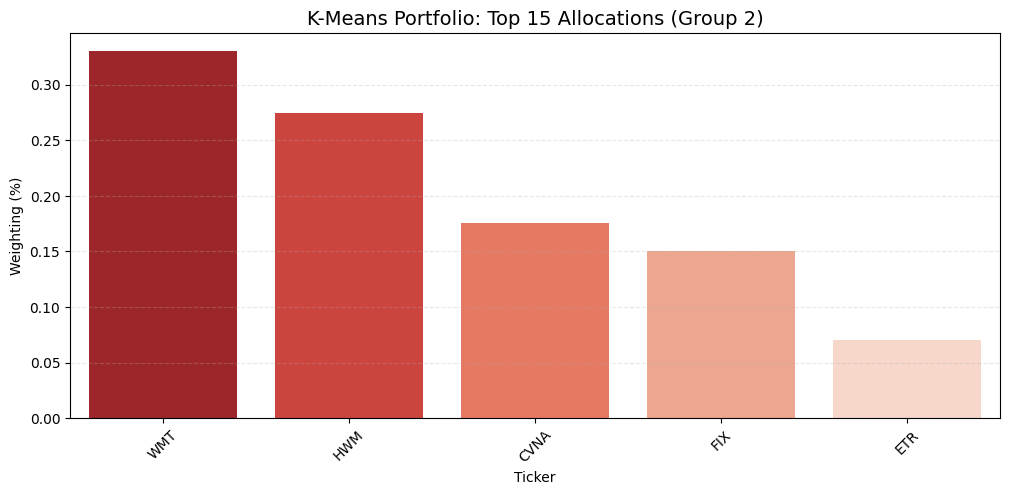


--- DEC Portfolio ANALYSIS ---
Total Selected Stocks (>0.1%): 6


C:\Users\AJITH\AppData\Local\Temp\ipykernel_1888\1931586362.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_holdings.head(15), x='Ticker', y='Weight', palette=color_palette)


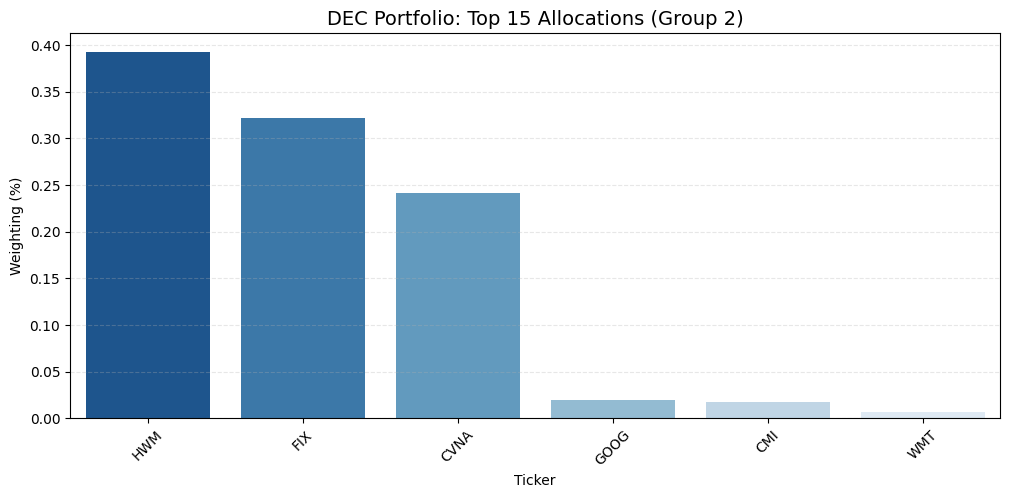


--- StyleDEC Portfolio ANALYSIS ---
Total Selected Stocks (>0.1%): 4


C:\Users\AJITH\AppData\Local\Temp\ipykernel_1888\1931586362.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_holdings.head(15), x='Ticker', y='Weight', palette=color_palette)


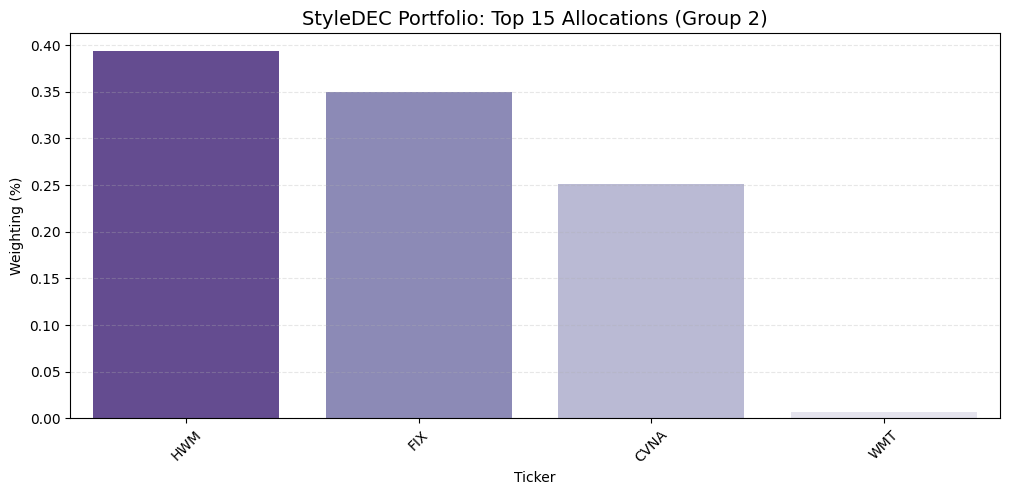


--- Equal-Weight Benchmark ANALYSIS ---
Total Selected Stocks (>0.1%): 100


C:\Users\AJITH\AppData\Local\Temp\ipykernel_1888\1931586362.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_holdings.head(15), x='Ticker', y='Weight', palette=color_palette)


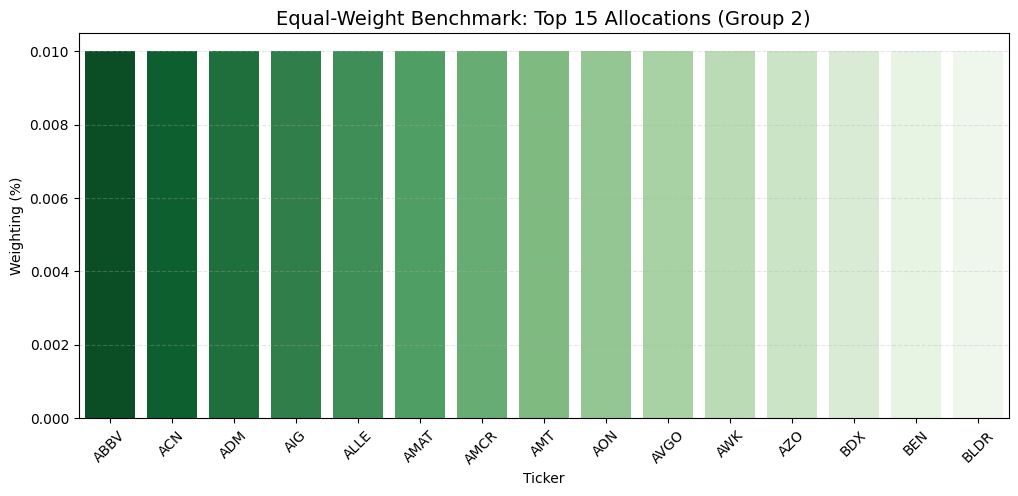

,Return,Volatility,Sharpe Ratio,Max Weight
Name,,,,
K-Means Portfolio,0.6594,0.2761,2.2433,0.3299
DEC Portfolio,0.7966,0.3928,1.9264,0.3930
StyleDEC Portfolio,0.8138,0.4057,1.9072,0.3930
Equal-Weight Benchmark,0.1293,0.1422,0.6277,0.0100


In [8]:
# Re-use your 'analyze_portfolio' function here...
stats_KM = analyze_portfolio(port_kmeans, "K-Means Portfolio", 'Reds_r')
stats_DEC = analyze_portfolio(port_dec, "DEC Portfolio", 'Blues_r')
stats_Style = analyze_portfolio(port_style, "StyleDEC Portfolio", 'Purples_r')
stats_Bench = analyze_portfolio(port_equal, "Equal-Weight Benchmark", 'Greens_r')

comparison_df = pd.DataFrame([stats_KM, stats_DEC, stats_Style, stats_Bench]).set_index('Name')
display(comparison_df.round(4))

### Backtesting

In [11]:
# --- BACKTESTING ENGINE ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def backtest_portfolio(weights_dict, log_returns, name):
    """
    Converts a weights dictionary into a daily equity curve.
    Returns a Series of cumulative returns.
    """
    # Align weights with return columns, fill missing tickers with 0
    w = pd.Series(weights_dict).reindex(log_returns.columns).fillna(0)
    
    # Normalise to ensure weights sum to 1 (handles floating point drift)
    w = w / w.sum()
    
    # Daily portfolio return = weighted sum of individual returns
    daily_returns = log_returns.dot(w)
    
    # Cumulative return curve (starts at 1.0 = $1 invested)
    cumulative = (1 + daily_returns).cumprod()
    cumulative.name = name
    
    return daily_returns, cumulative


def compute_metrics(daily_returns, cumulative, name, risk_free_rate=0.04):
    """
    Computes key performance metrics from daily returns and equity curve.
    """
    trading_days = 252
    
    # Annualised Return
    total_return = cumulative.iloc[-1] - 1
    n_years = len(daily_returns) / trading_days
    ann_return = (1 + total_return) ** (1 / n_years) - 1
    
    # Annualised Volatility
    ann_vol = daily_returns.std() * np.sqrt(trading_days)
    
    # Sharpe Ratio
    sharpe = (ann_return - risk_free_rate) / ann_vol
    
    # Maximum Drawdown
    rolling_max = cumulative.cummax()
    drawdown_series = (cumulative - rolling_max) / rolling_max
    max_dd = drawdown_series.min()
    
    # Calmar Ratio (Return / Max Drawdown) - popular in hedge funds
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    
    return {
        'Strategy': name,
        'Total Return': f"{total_return:.2%}",
        'Ann. Return': f"{ann_return:.2%}",
        'Ann. Volatility': f"{ann_vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd:.2%}",
        'Calmar Ratio': f"{calmar:.2f}"
    }


# --- RUN BACKTESTS ---
# Drop the first row (NaN from log return calculation)
log_ret_bt = log_returns.iloc[1:]

portfolios = {
    "K-Means":          port_kmeans,
    "DEC":              port_dec,
    "StyleDEC":         port_style,
    "Equal-Weight":     port_equal
}

daily_rets = {}
cum_rets   = {}
metrics    = []

for name, weights in portfolios.items():
    dr, cr = backtest_portfolio(weights, log_ret_bt, name)
    daily_rets[name] = dr
    cum_rets[name]   = cr
    metrics.append(compute_metrics(dr, cr, name))

metrics_df = pd.DataFrame(metrics).set_index('Strategy')
print("\n📊 BACKTEST PERFORMANCE SUMMARY")
print("="*70)
display(metrics_df)


📊 BACKTEST PERFORMANCE SUMMARY


,Total Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio
Strategy,,,,,,
K-Means,242.70%,86.27%,27.64%,2.98,-25.71%,3.36
DEC,316.28%,105.49%,39.31%,2.58,-32.62%,3.23
StyleDEC,326.31%,107.98%,40.61%,2.56,-33.44%,3.23
Equal-Weight,26.67%,12.68%,14.24%,0.61,-16.58%,0.76


### Backtesting Visualisation

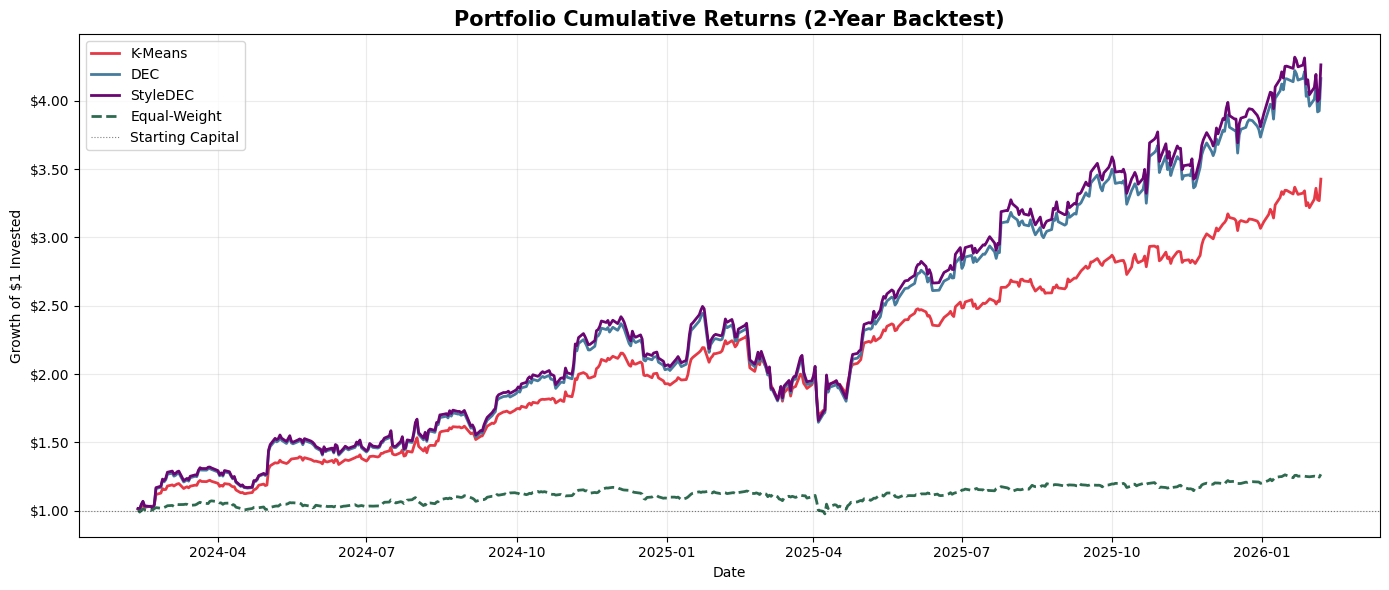

In [12]:
# --- VISUALISATION 1: CUMULATIVE RETURN CURVES ---
fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    "K-Means":      "#E63946",
    "DEC":          "#457B9D",
    "StyleDEC":     "#6A0572",
    "Equal-Weight": "#2D6A4F"
}
styles = {
    "K-Means":      "-",
    "DEC":          "-",
    "StyleDEC":     "-",
    "Equal-Weight": "--"   # Dashed to visually mark it as benchmark
}

for name, curve in cum_rets.items():
    ax.plot(curve.index, curve.values,
            label=name,
            color=colors[name],
            linestyle=styles[name],
            linewidth=2)

ax.axhline(1.0, color='black', linewidth=0.8, linestyle=':', alpha=0.5, label='Starting Capital')
ax.set_title("Portfolio Cumulative Returns (2-Year Backtest)", fontsize=15, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 Invested")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y:.2f}"))
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

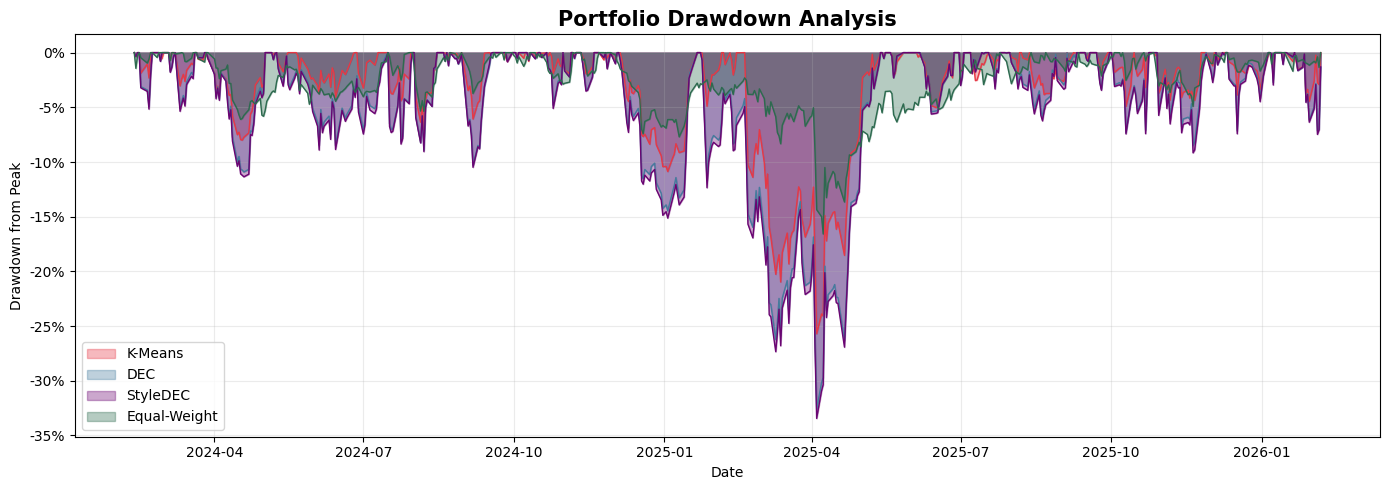

In [13]:
# --- VISUALISATION 2: DRAWDOWN CHART ---
fig, ax = plt.subplots(figsize=(14, 5))

for name, curve in cum_rets.items():
    rolling_max = curve.cummax()
    drawdown = (curve - rolling_max) / rolling_max
    ax.fill_between(drawdown.index, drawdown.values, 0,
                    alpha=0.35, color=colors[name], label=name)
    ax.plot(drawdown.index, drawdown.values,
            color=colors[name], linewidth=1)

ax.set_title("Portfolio Drawdown Analysis", fontsize=15, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown from Peak")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(loc='lower left', frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

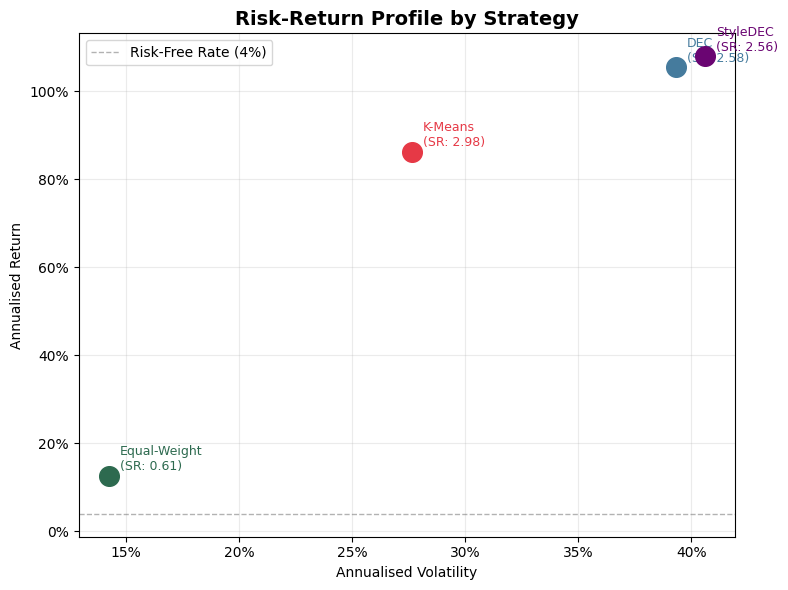

In [14]:
# --- VISUALISATION 4: RISK-RETURN SCATTER ---
fig, ax = plt.subplots(figsize=(8, 6))

for row in metrics:
    name = row['Strategy']
    vol  = float(row['Ann. Volatility'].strip('%')) / 100
    ret  = float(row['Ann. Return'].strip('%'))    / 100
    sr   = float(row['Sharpe Ratio'])
    
    ax.scatter(vol, ret, s=200, color=colors[name], zorder=5)
    ax.annotate(
        f"{name}\n(SR: {sr:.2f})",
        xy=(vol, ret),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=9,
        color=colors[name]
    )

ax.axhline(0.04, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='Risk-Free Rate (4%)')
ax.set_title("Risk-Return Profile by Strategy", fontsize=14, fontweight='bold')
ax.set_xlabel("Annualised Volatility")
ax.set_ylabel("Annualised Return")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()